In [ ]:
%pip install spacy -q
import nltk
import sklearn
import spacy
nltk.download("punkt")

614.36s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to /Users/ramj/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [51]:
plain_text="""This is an example of my text for ai learning. A mischievous group of playful kittens, their tiny paws padding softly on the worn wooden floor, chased a bright red laser pointer dot, their eyes wide with excitement and anticipation, as it danced erratically across the room.
"""
exp=r'[^a-zA-Z]'
import re
alpha_pattern=re.compile(exp)
my_text=re.sub(alpha_pattern,' ',plain_text)
print(my_text)
my_text=my_text.strip()

This is an example of my text for ai learning  A mischievous group of playful kittens  their tiny paws padding softly on the worn wooden floor  chased a bright red laser pointer dot  their eyes wide with excitement and anticipation  as it danced erratically across the room  


In [52]:


from nltk.tokenize import word_tokenize,sent_tokenize
sents=sent_tokenize(my_text)
for sent in sents:
    print(sent)
w_tokens=word_tokenize(my_text)



This is an example of my text for ai learning  A mischievous group of playful kittens  their tiny paws padding softly on the worn wooden floor  chased a bright red laser pointer dot  their eyes wide with excitement and anticipation  as it danced erratically across the room


In [15]:
import matplotlib.pyplot as plot

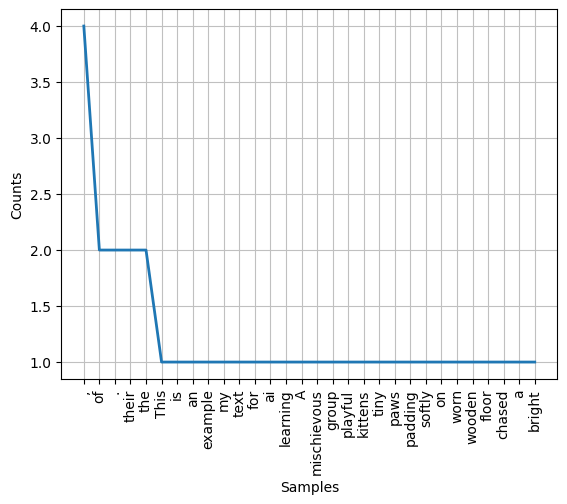

In [24]:
from nltk.probability import FreqDist
fd=FreqDist(w_tokens)
fd.most_common(n=4)
fd.plot(30,cumulative=False)
plot.show()


In [25]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /Users/ramj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
from nltk.corpus import stopwords
eng_stop_words=stopwords.words("english")

In [40]:
eng_stop_words[:10]
# import seaborn as sns
# sns.catplot(data=eng_stop_words,orient='h')
# plot.xticks(rotation=90)
# plot.Figure(figsize=(50,100))
# plot.show()

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

179 31


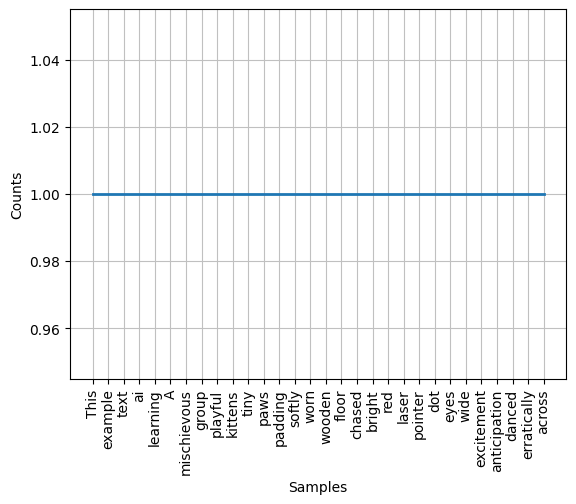

<Axes: xlabel='Samples', ylabel='Counts'>

In [53]:

eng_stop_words=set(eng_stop_words)


cleaned_without_stop_words=[word for word in w_tokens if word not in eng_stop_words]
print(len(eng_stop_words),len(cleaned_without_stop_words))
new_fd=FreqDist(cleaned_without_stop_words)
new_fd.plot(30)


In [54]:
#cleaned_without_stop_words
from nltk.stem import PorterStemmer
stemmer=PorterStemmer()
stemmer.stem("ran")
cleaned_without_stop_words_stemmed=[stemmer.stem(word) for word in cleaned_without_stop_words ]
print(cleaned_without_stop_words)
print(cleaned_without_stop_words_stemmed)

['This', 'example', 'text', 'ai', 'learning', 'A', 'mischievous', 'group', 'playful', 'kittens', 'tiny', 'paws', 'padding', 'softly', 'worn', 'wooden', 'floor', 'chased', 'bright', 'red', 'laser', 'pointer', 'dot', 'eyes', 'wide', 'excitement', 'anticipation', 'danced', 'erratically', 'across', 'room']
['thi', 'exampl', 'text', 'ai', 'learn', 'a', 'mischiev', 'group', 'play', 'kitten', 'tini', 'paw', 'pad', 'softli', 'worn', 'wooden', 'floor', 'chase', 'bright', 'red', 'laser', 'pointer', 'dot', 'eye', 'wide', 'excit', 'anticip', 'danc', 'errat', 'across', 'room']


In [55]:
nltk.download("wordnet")
nltk.download("vader_lexicon")


[nltk_data] Downloading package wordnet to /Users/ramj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ramj/nltk_data...


True

In [56]:
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
sia=SentimentIntensityAnalyzer()

In [ ]:
sia.polarity_scores("this is my test fo ai ml, good to lean this awesome subject")

{'neg': 0.0, 'neu': 0.586, 'pos': 0.414, 'compound': 0.8305}

In [63]:
# cleaned_without_stop_words_stemmed
sia.polarity_scores("".join(cleaned_without_stop_words_stemmed))

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}